<a href="https://colab.research.google.com/github/phuc-tran7/CMSC426/blob/homework1/CMSC426_Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**UID: 119003923**

**Name: Phuc Tran**

# **Introduction**

This homework is designed to test your understanding of mathematics tutorial discussed in this [link](https://cmsc426.github.io/math-tutorial/), specifically [RANSAC](https://cmsc426.github.io/math-tutorial#ransac). We highly recommend you to read the entire math tutorial, not just the RANSAC section. **The task is to fit the best possible line to two dimensional data points** using linear least square techniques discussed in the tutorial such that the line defines the best possible set of data points:

- Basics of Linear Algebra
- Line fitting using Linear Least Squares
- Outliers rejection using RANSAC



# **Revision: Vectors, Matrices, Eigenvalues, and Eigenvectors (Optional)**

Before we dive into the main tasks, let's quickly revise some key mathematical concepts: vectors, matrices, eigenvalues, and eigenvectors.

**NOTE:** This section is optional and not graded. If you are already familar with the algebra and numpy, you can ignore this step.

### **Given Matrix**

You are provided with the following 2D array (matrix):

$$
A = \begin{pmatrix} 4 & 2 \\ 1 & 3 \end{pmatrix}
$$

### **STEP 1: Calculate Covariance:**
Covariance is a measure of how two variables change together.

To calculate the covariance matrix for a 2D dataset:

1. **Compute the Mean:** Calculate the mean of each variable (column) in the matrix.
2. **Center the Data:** Subtract the mean from each corresponding data point.
3. **Calculate the Covariance Matrix:** Use the formula:

$$
C = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
$$

For a 2D matrix \( A \), the covariance matrix \( C \) is:

$$
C = \begin{pmatrix}
\text{var}(x) & \text{cov}(x, y) \\
\text{cov}(x, y) & \text{var}(y)
\end{pmatrix}
$$

Finally, you can verify the result using NumPy's inbuilt function.

### **Step 2: Calculate Eigenvalues and Eigenvectors**

1. **Find the characteristic equation:**

   1.1 The characteristic equation is given by:

   $$
   \text{det}(A - \lambda I) = 0
   $$

   1.2 Expanding the determinant and simplify

   1.3 Solving the quadratic equation for get eigen values $\lambda$


2. **Find the eigenvectors:**


2.1 For each eigenvalue \( $\lambda_1 $) and ( $\lambda_2 $), substitute back into the equation \( ($A - \lambda I)v = 0 $) to find the corresponding eigenvector \($ v $).



# **What you need to do?  [TOTAL: 75 POINTS]**
The 2D points data is provided in the form of .mat file. The visualization of data with different noise level is shown in the following figure.

In [32]:
import scipy
import gdown
gdown.download_folder(id="1HceecW7W9GGocCrgAC0TNL9_7DrEgfeB", quiet=True, use_cookies=False)
data1 = scipy.io.loadmat("/content/data/data1.mat")["pts"]
data2 = scipy.io.loadmat("/content/data/data2.mat")["pts"]
data3 = scipy.io.loadmat("/content/data/data3.mat")["pts"]

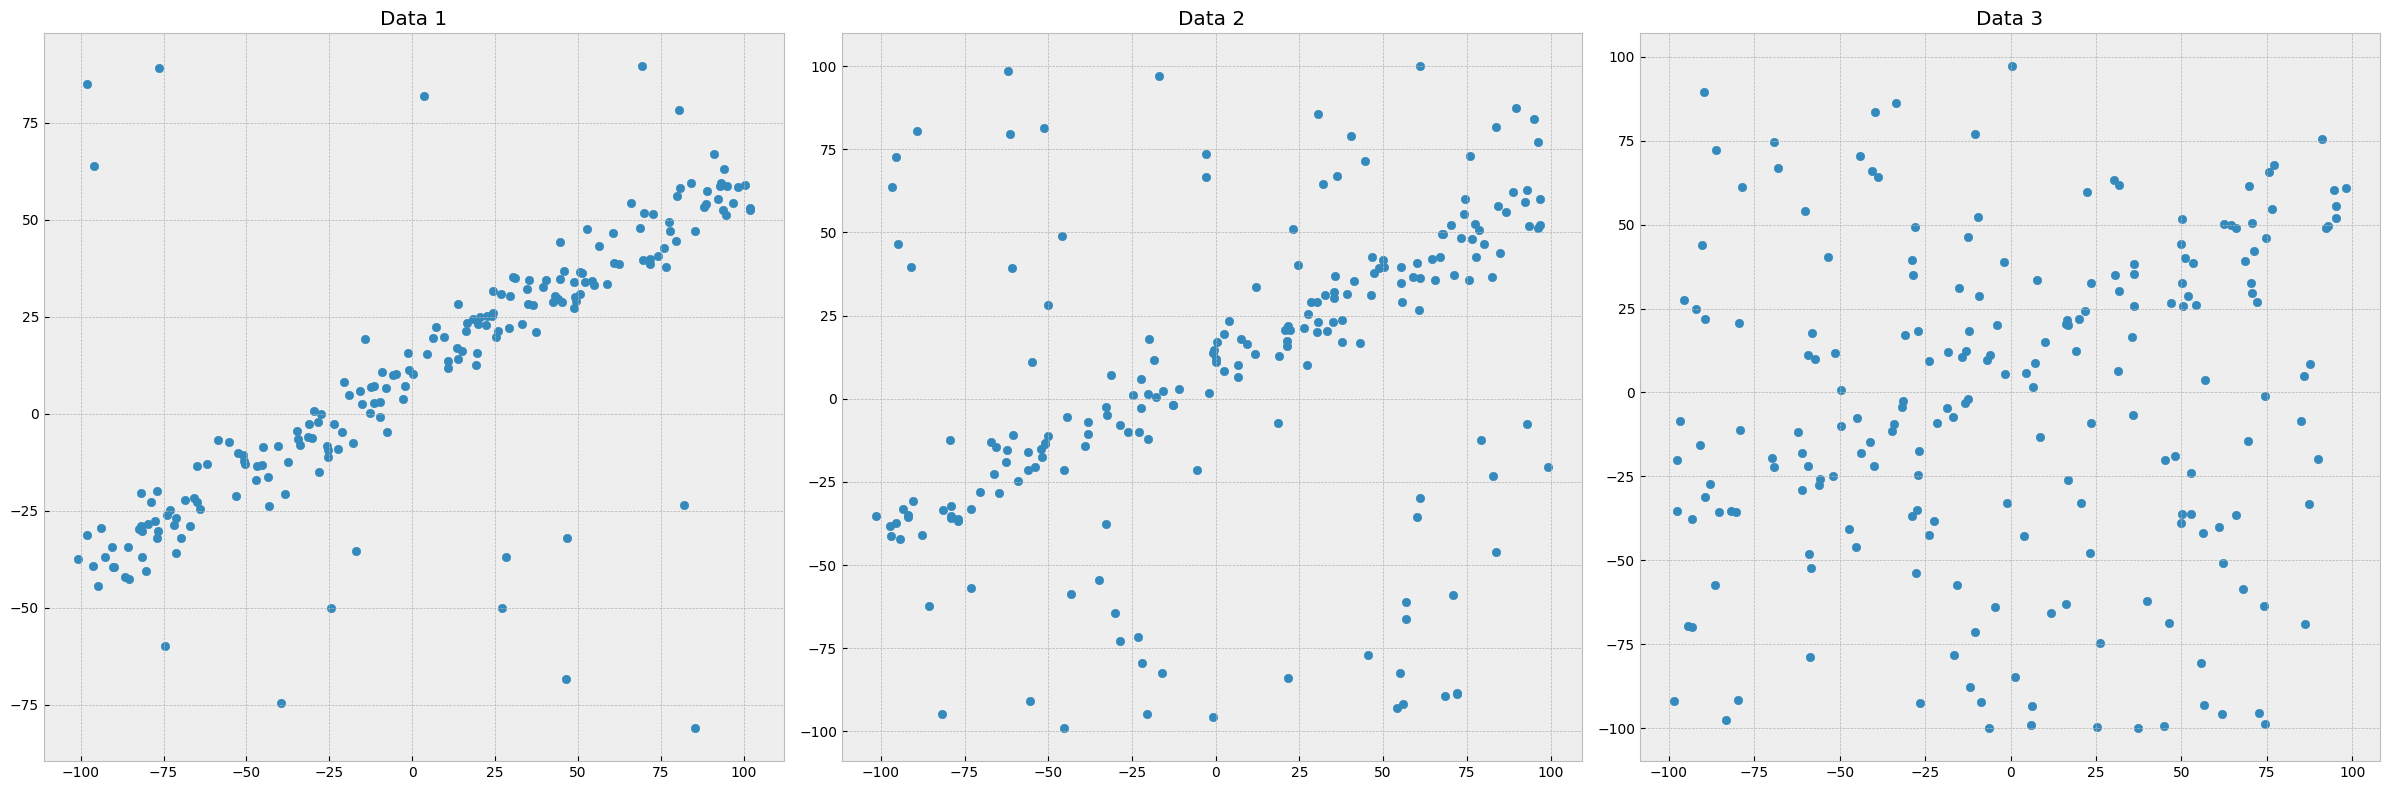

In [33]:
import matplotlib.pyplot as plt
from matplotlib import style
plt.style.use("bmh")

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
axes[0].scatter(data1[0],data1[1])
axes[0].set_title('Data 1')

axes[1].scatter(data2[0],data2[1])
axes[1].set_title('Data 2')

axes[2].scatter(data3[0],data3[1])
axes[2].set_title('Data 3')

plt.tight_layout()
plt.show()

### **STEP 1: Visualize geometric interpretation [20 points]**
Visualize geometric interpretation of eigenvalues/covariance matrix as shown in Fig. 10 of this [link](http://www.visiondummy.com/2014/04/geometric-interpretation-covariance-matrix/)

covaraince of Data 1 : [[3407.3108669  1473.06388943]
 [1473.06388943 1169.53151003]]
eigen value of Data 1 : [4138.24045932  438.60191761]
eigen vector of Data 1 : [[ 0.89578578 -0.44448604]
 [ 0.44448604  0.89578578]]
covaraince of Data 2 : [[3418.29090234 1039.75748627]
 [1039.75748627 2177.72593476]]
eigen value of Data 2 : [4008.72968704 1587.28715007]
eigen vector of Data 2 : [[ 0.86957598 -0.49379917]
 [ 0.49379917  0.86957598]]
covaraince of Data 3 : [[3086.14137209  326.06544037]
 [ 326.06544037 2369.3509072 ]]
eigen value of Data 3 : [3212.27252081 2243.21975848]
eigen vector of Data 3 : [[ 0.93265255 -0.36077585]
 [ 0.36077585  0.93265255]]


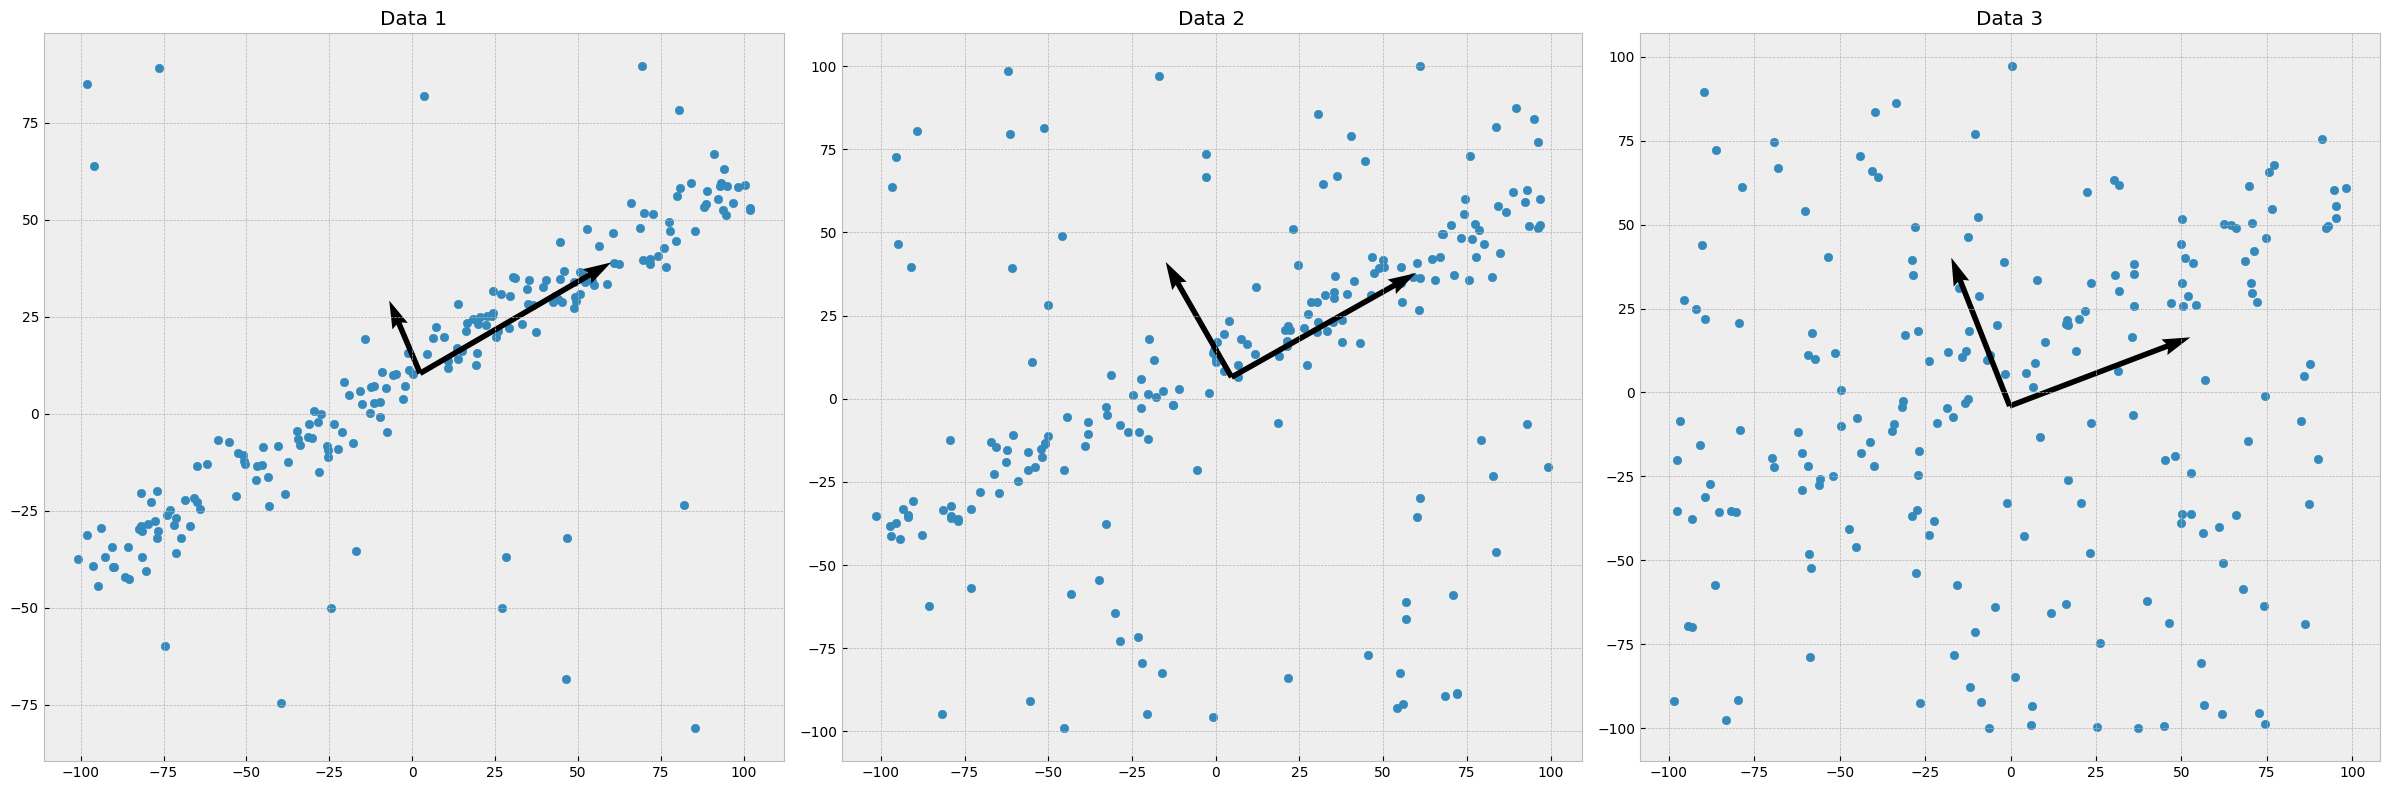

In [34]:
# hint: you can use https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html for plotting the axes

import matplotlib.pyplot as plt
from matplotlib import style
import numpy as np
plt.style.use("bmh")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

#Data 1
axes[0].scatter(data1[0],data1[1])
axes[0].set_title('Data 1')
# calculate covar and then find eigen vector/val, use means, eigen vactor/val to quiver
print(f"covaraince of Data 1 : {np.cov(data1[0],data1[1])}")
dataOneCoVar = np.cov(data1[0],data1[1])
dataOneEigenValue, dataOneEigenVector = np.linalg.eig(dataOneCoVar) #eigenvector gives direction for quiver (u,v), eigenval for scale length
print(f"eigen value of Data 1 : {dataOneEigenValue}")
print(f"eigen vector of Data 1 : {dataOneEigenVector}")
x = data1[0]
y = data1[1]
# x is mean of x, y is mean of y, always
# u is first ele of column 1 of eigenvector times sqrt first ele eigenvalue
# v is second ele of colum 1 of eigenvector times sqrt first ele eigen value
axes[0].quiver(np.mean(x),np.mean(y),(dataOneEigenVector[:,0][0])*np.sqrt(dataOneEigenValue[0]),(dataOneEigenVector[:,0][1])*np.sqrt(dataOneEigenValue[0]),scale=1, scale_units='xy', angles='xy')
# u is first ele of column 2 of eigenvector times sqrt 2nd ele eigenvalue
# v is second ele of colum 2 of eigenvector times sqrt 2nd ele eigen value
axes[0].quiver(np.mean(x),np.mean(y),(dataOneEigenVector[:,1][0])*np.sqrt(dataOneEigenValue[1]),(dataOneEigenVector[:,1][1])*np.sqrt(dataOneEigenValue[1]),scale=1, scale_units='xy', angles='xy')


#Data 2
axes[1].scatter(data2[0],data2[1])
axes[1].set_title('Data 2')
# calculate covar and then find eigen vector/val, use means, eigen vactor/val to quiver
print(f"covaraince of Data 2 : {np.cov(data2[0],data2[1])}")
dataTwoCoVar = np.cov(data2[0],data2[1])
dataTwoEigenValue, dataTwoEigenVector = np.linalg.eig(dataTwoCoVar) #eigenvector gives direction for quiver (u,v), eigenval for scale length
print(f"eigen value of Data 2 : {dataTwoEigenValue}")
print(f"eigen vector of Data 2 : {dataTwoEigenVector}")
x = data2[0]
y = data2[1]
# x is mean of x, y is mean of y, always
# u is first ele of column 1 of eigenvector times sqrt first ele eigenvalue
# v is second ele of colum 1 of eigenvector times sqrt first ele eigen value
axes[1].quiver(np.mean(x),np.mean(y),(dataTwoEigenVector[:,0][0])*np.sqrt(dataTwoEigenValue[0]),(dataTwoEigenVector[:,0][1])*np.sqrt(dataTwoEigenValue[0]),scale=1, scale_units='xy', angles='xy')
# u is first ele of column 2 of eigenvector times sqrt 2nd ele eigenvalue
# v is second ele of colum 2 of eigenvector times sqrt 2nd ele eigen value
axes[1].quiver(np.mean(x),np.mean(y),(dataTwoEigenVector[:,1][0])*np.sqrt(dataTwoEigenValue[1]),(dataTwoEigenVector[:,1][1])*np.sqrt(dataTwoEigenValue[1]),scale=1, scale_units='xy', angles='xy')


#Data 3
axes[2].scatter(data3[0],data3[1])
axes[2].set_title('Data 3')
# calculate covar and then find eigen vector/val, use means, eigen vactor/val to quiver
print(f"covaraince of Data 3 : {np.cov(data3[0],data3[1])}")
dataThreeCoVar = np.cov(data3[0],data3[1])
dataThreeEigenValue, dataThreeEigenVector = np.linalg.eig(dataThreeCoVar) #eigenvector gives direction for quiver (u,v), eigenval for scale length
print(f"eigen value of Data 3 : {dataThreeEigenValue}")
print(f"eigen vector of Data 3 : {dataThreeEigenVector}")
x = data3[0]
y = data3[1]
# x is mean of x, y is mean of y, always
# u is first ele of column 1 of eigenvector times sqrt first ele eigenvalue
# v is second ele of colum 1 of eigenvector times sqrt first ele eigen value
axes[2].quiver(np.mean(x),np.mean(y),(dataThreeEigenVector[:,0][0])*np.sqrt(dataThreeEigenValue[0]),(dataThreeEigenVector[:,0][1])*np.sqrt(dataThreeEigenValue[0]),scale=1, scale_units='xy', angles='xy')
# u is first ele of column 2 of eigenvector times sqrt 2nd ele eigenvalue
# v is second ele of colum 2 of eigenvector times sqrt 2nd ele eigen value
axes[2].quiver(np.mean(x),np.mean(y),(dataThreeEigenVector[:,1][0])*np.sqrt(dataThreeEigenValue[1]),(dataThreeEigenVector[:,1][1])*np.sqrt(dataThreeEigenValue[1]),scale=1, scale_units='xy', angles='xy')


plt.tight_layout()
plt.show()

###**STEP 2: RANSAC Implementation [35 points]**

1. **Random Sampling:**
   - Randomly select two data points.

2. **Line Equation:**
   - Calculate the slope \($m$) and intercept \($c$) of the line.


3. **Distance Calculation:**
   - For each data point \((x_i, y_i)\), compute the perpendicular distance to the line:
   - Count the points where this distance is less than a predefined threshold as inliers.

4. **Iteration:**
   - Repeat steps 1-3 for a set number of iterations, keeping track of the line equation with the highest inlier count.

5. **Final Model:**
   - Return the slope and intercept of the line with the most inliers and visualize it.


In [35]:
def RANSAC(X,Y):
  #write the function here follwoing the steps above.
  x = X
  y = Y
  threshold = 5
  largestCount = 0
  finalX1 = None
  finalX2 = None
  finalY1 = None
  finalY2 = None
  finalM = None
  finalC = None

  for i in range(0,20,1):
    # 1 Random sampling
    indices = np.random.choice(len(x), size=2, replace=False)
    x1 = x[indices[0]]
    y1 = y[indices[0]]
    x2 = x[indices[1]]
    y2 = y[indices[1]]


    # 2 line equation
    m = (y2-y1)/(x2-x1)
    c = y2 - (m*x2) # y = mx + b; b = y - mx;


    # 3 Perpendicular Distance calculation
    count = 0
    for j in range(0,len(x),1):
      x0 = x[j]
      y0 = y[j]

      # perpendicular distance formula: |A·x₀ + B·y₀ + C| / √(A² + B²), where Ax + By + C = 0 and mx - y + c = 0
      distance = abs(m*x0 - y0 + c) / np.sqrt(m**2 + 1)
      if distance <= threshold:
        count+=1

    if count > largestCount:
      largestCount = count
      finalX1 = x1
      finalX2 = x2
      finalY1 = y1
      finalY2 = y2
      finalM = m
      finalC = c
  print(f"data point 1: ({finalX1},{finalY1})")
  print(f"data point 2: ({finalX2},{finalY2}")
  print(f"slope: {finalM}")
  print(f"intercept: {finalC}")
  return [finalM, finalC]

RANSAC(data1[0],data1[1])



data point 1: (-100.91571299147951,-37.50262435490796)
data point 2: (33.294231447138905,23.238522462002383
slope: 0.45258305612882965
intercept: 8.17011744219567


[np.float64(0.45258305612882965), np.float64(8.17011744219567)]

###**STEP 3: Final Visualization [20 points]**
Final Visualization

data point 1: (-73.93095092151674,-26.18104431440237)
data point 2: (88.17801899004456,53.313210124001706
slope: 0.4903754214327082
intercept: 10.072876900657256
data point 1: (21.65502564350786,21.919299315926715)
data point 2: (39.244746601808814,31.604330666827675
slope: 0.5506074470345929
intercept: 9.995880930886212
data point 1: (-40.984462198080124,-14.904767494785734)
data point 2: (-31.888029069088983,-4.45705186572791
slope: 1.1485508089714886
intercept: 32.167969718080585


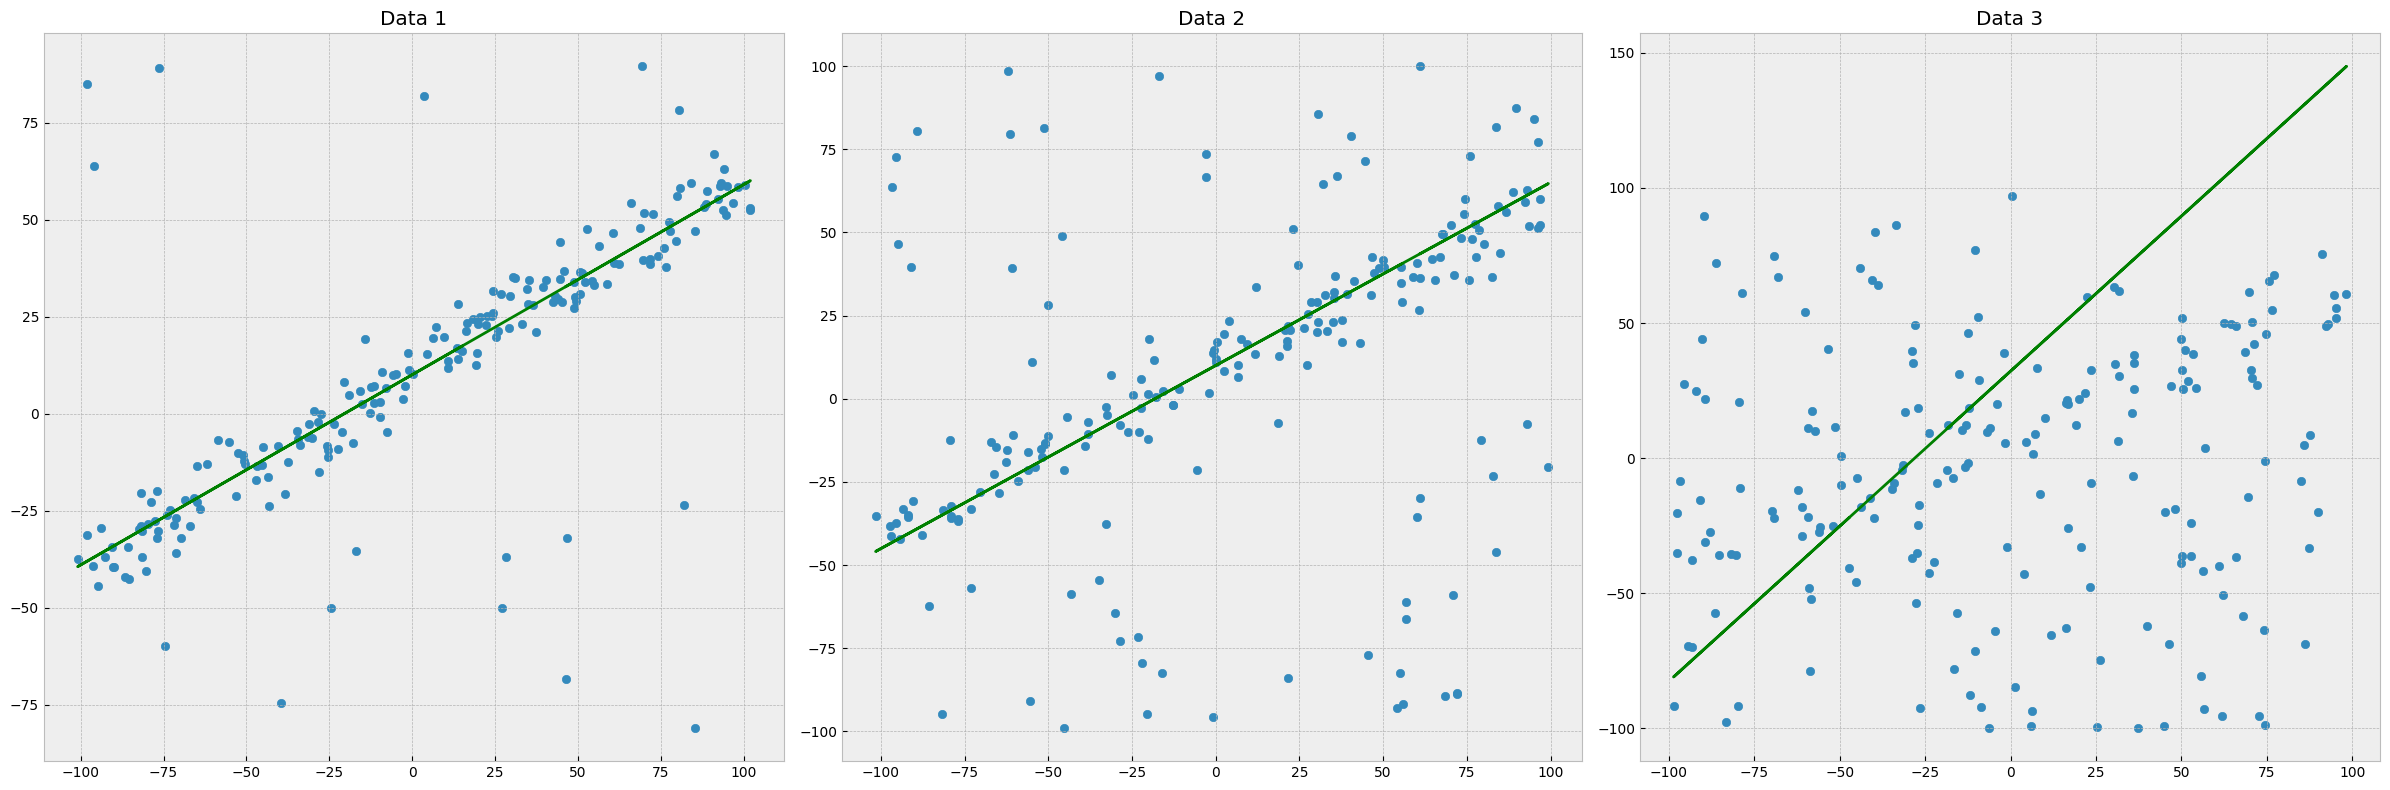

In [42]:
# Apply RANSAC to all three datasets
datasets = [data1, data2, data3]
titles = ['Data 1', 'Data 2', 'Data 3']

#write your code here
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
axes[0].scatter(data1[0],data1[1])
axes[0].set_title('Data 1')
#ransac one and then plot the y = mx+b
ransacOne = RANSAC(data1[0],data1[1])
axes[0].plot(data1[0],ransacOne[0]*data1[0]+ransacOne[1],color='green')



axes[1].scatter(data2[0],data2[1])
axes[1].set_title('Data 2')
#ransac two and then plot the y = mx+b
ransacTwo = RANSAC(data2[0],data2[1])
axes[1].plot(data2[0],ransacTwo[0]*data2[0]+ransacTwo[1],color='green' )



axes[2].scatter(data3[0],data3[1])
axes[2].set_title('Data 3')
#ransac three and then plot the y = mx+b
ransacThree = RANSAC(data3[0],data3[1])
axes[2].plot(data3[0],ransacThree[0]*data3[0]+ransacThree[1],color='green')

plt.tight_layout()
plt.show()

# **Report [TOTAL: 25 POINTS]**
For each section of the homework, below are certain questions to check your understanding.

### **Problem 1: Linear Algebra Concepts** [12 Points]

1) Define Eigenvalues and Eigenvectors? What is the physical  meaning of it? [4 points]

2) What is the least squares method, and why is it important for fitting a line to data in linear regression? [4 points]

3) What is SVD (Singular Value Decomoposition) and its meaning for real-world application? [4 points]


Answers:

### **Problem 2: RANSAC Understanding** [7 points]

1) Discuss a scenario where the RANSAC algorithm might fail or be less effective. How could the algorithm be adjusted or combined with other techniques to mitigate this issue? [5 points]

2) How do the number of iterations and the inlier threshold in RANSAC affect the algorithm’s outcome? [2 points]

### **Problem 3: Null Space, Column Space and Rank of Matrix** [6 POINTS]

1)Define the nullspace, column space, and rank of a matrix. How are these concepts related? [3 points]

2) How does the rank of the matrix relate to its nullspace and column space? [3 points]




# Submission Guidelines

**If your submission does not comply with the following guidelines, you’ll be given ZERO credit.**

Your submission on ELMS(Canvas) must be a pdf file, following the naming convention **YourDirectoryID_hw1.pdf**. For example, xyz123_hw1.pdf.